# Импорт библиотек

In [2]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import sys
import random
import subprocess
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

NumPy: 2.3.5
Pandas: 2.3.3
FAISS available: True


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    
    try:
        import torch
        torch.manual_seed(seed)
        # Дополнительно для CUDA (если используется)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)  
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass  # torch не установлен


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


In [4]:
import matplotlib.pyplot as plt

# Сборка базы данных
**Выбранная база знаний:** История технологий и изобретений.

**Почему эта тема:**
- Документы содержат конкретные факты (даты, имена, технологии)
- Позволяет задавать разнообразные фактологические вопросы
- Темы пересекаются, что создаёт интересные кейсы для retrieval
- 12 документов, после чанкинга даёт ~30-50 фрагментов

In [5]:
# Новая база знаний: История технологий и изобретений
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Изобретение транзистора",
        "text": (
            "Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. "
            "Это изобретение заменило громоздкие вакуумные лампы и позволило создавать миниатюрные электронные устройства. "
            "Транзисторы стали основой для компьютеров, мобильных телефонов и всей современной электроники. "
            "За это открытие ученые получили Нобелевскую премию по физике в 1956 году."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Создание интернета",
        "text": (
            "Интернет берет начало в сети ARPANET, созданной в 1969 году Министерством обороны США. "
            "Первоначально сеть соединяла всего 4 университетских компьютера. "
            "В 1983 году был внедрен протокол TCP/IP, который стал стандартом для передачи данных. "
            "В 1991 году Тим Бернерс-Ли изобрел World Wide Web, предложив HTTP, HTML и первые веб-браузеры, "
            "что сделало интернет доступным для широкой публики."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Персональные компьютеры",
        "text": (
            "Первым массовым персональным компьютером стал Altair 8800 в 1975 году. "
            "В 1976 году Стив Джобс и Стив Возняк основали Apple и выпустили Apple I. "
            "В 1981 году IBM представила свой первый персональный компьютер с открытой архитектурой, "
            "что позволило другим производителям создавать совместимые устройства. "
            "Microsoft разработала MS-DOS, а затем Windows, сделав компьютеры доступными для миллионов пользователей."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "История искусственного интеллекта",
        "text": (
            "Термин 'искусственный интеллект' был предложен в 1956 году на Дартмутской конференции. "
            "В 1997 году компьютер IBM Deep Blue победил чемпиона мира по шахматам Гарри Каспарова. "
            "В 2012 году нейронные сети показали прорыв в распознавании изображений. "
            "В 2016 году программа AlphaGo от Google DeepMind победила чемпиона мира по игре Го, "
            "что считалось недостижимым для ИИ еще за несколько лет до этого."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Развитие мобильной связи",
        "text": (
            "Первый коммерческий сотовый телефон Motorola DynaTAC 8000X появился в 1983 году. "
            "Он весил почти 1 кг и стоил около 4000 долларов. "
            "В 1992 году было отправлено первое SMS-сообщение. "
            "В 2007 году Apple представила iPhone, который совершил революцию в мобильной индустрии, "
            "предложив сенсорный экран и полноценную мобильную операционную систему."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Изобретение микропроцессора",
        "text": (
            "Первый микропроцессор Intel 4004 был создан в 1971 году. "
            "Он содержал 2300 транзисторов и работал на частоте 740 кГц. "
            "Микропроцессоры позволили создавать программируемые калькуляторы, "
            "а затем и персональные компьютеры. "
            "Сегодня современные процессоры содержат миллиарды транзисторов и "
            "используют передовые технологии с нормами 3-5 нанометров."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Технология Bluetooth",
        "text": (
            "Bluetooth был разработан в 1994 году компанией Ericsson как беспроводная альтернатива кабелям. "
            "Название происходит от датского короля Харальда Синезубого (Bluetooth), объединившего племена. "
            "Стандарт Bluetooth 1.0 появился в 1999 году. "
            "Сегодня Bluetooth используется в наушниках, колонках, клавиатурах и для передачи файлов. "
            "Bluetooth Low Energy (BLE) позволяет создавать устройства с очень низким энергопотреблением."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "История видеоигр",
        "text": (
            "Первой коммерческой видеоигрой стала Computer Space в 1971 году. "
            "В 1972 году Atari выпустила Pong — простейший симулятор настольного тенниса. "
            "В 1980-х Nintendo спасла индустрию после кризиса, выпустив NES и игру Super Mario Bros. "
            "В 1990-х появились 3D-игры и такие консоли, как PlayStation и Nintendo 64. "
            "Сегодня индустрия видеоигр приносит больше дохода, чем кино и музыка вместе взятые."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Создание WWW и веб-технологий",
        "text": (
            "Тим Бернерс-Ли в 1989 году предложил концепцию Всемирной паутины, работая в CERN. "
            "Он создал первый веб-сервер, первый веб-браузер и язык HTML. "
            "В 1993 году CERN объявил, что WWW будет бесплатной для всех. "
            "Появились первые поисковые системы: WebCrawler, Yahoo, а затем Google. "
            "Сегодня веб-технологии включают HTML5, CSS3, JavaScript и множество фреймворков."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Искусственный интеллект в повседневной жизни",
        "text": (
            "ИИ уже используется в распознавании лиц на смартфонах и в системах безопасности. "
            "Рекомендательные системы YouTube, Netflix и Spotify анализируют наши предпочтения. "
            "Голосовые помощники Siri, Alexa и Google Assistant понимают естественную речь. "
            "В медицине ИИ помогает диагностировать заболевания по снимкам МРТ и рентгена. "
            "Автопилоты Tesla используют глубокое обучение для распознавания объектов на дороге."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Эволюция операционных систем",
        "text": (
            "В 1969 году в Bell Labs создали UNIX — многопользовательскую ОС. "
            "В 1985 году Microsoft выпустила Windows 1.0, графическую оболочку для MS-DOS. "
            "В 1991 году Линус Торвальдс создал Linux, свободную UNIX-подобную ОС. "
            "Apple в 2001 году представила Mac OS X на основе NeXTSTEP. "
            "Сегодня доминируют Windows, macOS, Linux и мобильные ОС — Android и iOS."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Будущее технологий и тренды",
        "text": (
            "Квантовые компьютеры обещают решать задачи, недоступные классическим компьютерам. "
            "Искусственный интеллект продолжает развиваться, появляются генеративные модели, "
            "способные создавать текст, изображения и видео. "
            "Интернет вещей (IoT) соединяет миллиарды устройств. "
            "Нейроинтерфейсы, такие как разработки Neuralink, могут изменить взаимодействие "
            "человека с компьютером. "
            "Блокчейн и криптовалюты предлагают новые модели децентрализованных систем."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]])

Размер корпуса: 12


,doc_id,title
0,doc_01,Изобретение транзистора
1,doc_02,Создание интернета
2,doc_03,Персональные компьютеры
3,doc_04,История искусственного интеллекта
4,doc_05,Развитие мобильной связи
5,doc_06,Изобретение микропроцессора
6,doc_07,Технология Bluetooth
7,doc_08,История видеоигр
8,doc_09,Создание WWW и веб-технологий
9,doc_10,Искусственный интеллект в повседневной жизни


# Чанкинг документов
**Выбранные параметры:**
- `chunk_size = 28` слов (баланс между контекстом и точностью)
- `overlap = 8` слов (чтобы важная мысль не разрывалась на границе)

**Почему такие параметры:**
- 28 слов достаточно для передачи законченной мысли
- Overlap 8 слов (около 30%) обеспечивает плавный переход между чанками
- При таком размере получается оптимальное количество чанков для учебного корпуса

In [6]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)

# Показываем пример чанкинга на одном документе
sample_doc = documents[0]
sample_chunks = chunk_text(sample_doc["text"], chunk_size=28, overlap=8)

print(f"Документ: {sample_doc['title']}")
print(f"Исходный текст: {sample_doc['text'][:150]}...")
print(f"\nКоличество чанков: {len(sample_chunks)}")
print("\nПримеры чанков:")
for i, chunk in enumerate(sample_chunks[:2]):
    print(f"\nЧанк {i+1}:")
    print(f"  {chunk[:150]}...")
    print(f"  Длина: {len(chunk.split())} слов")

# Построение всех чанков
def build_chunks(documents: List[Dict[str, str]], chunk_size: int = 28, overlap: int = 8) -> List[Dict]:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": chunk_idx,
                "chunk_text": chunk_text_value,
            })
    return pd.DataFrame(rows)


chunks_df = build_chunks(documents, chunk_size=28, overlap=8)
print(f"\nВсего чанков: {len(chunks_df)}")
display(chunks_df.head())

Документ: Изобретение транзистора
Исходный текст: Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. Это изобретение заменило громо...

Количество чанков: 3

Примеры чанков:

Чанк 1:
  Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном. Это изобретение заменило громо...
  Длина: 28 слов

Чанк 2:
  громоздкие вакуумные лампы и позволило создавать миниатюрные электронные устройства. Транзисторы стали основой для компьютеров, мобильных телефонов и ...
  Длина: 28 слов

Всего чанков: 33


,doc_id,title,chunk_id,chunk_text
0,doc_01,Изобретение транзистора,0,Транзистор был изобретен в Bell Laboratories в...
1,doc_01,Изобретение транзистора,1,громоздкие вакуумные лампы и позволило создава...
2,doc_01,Изобретение транзистора,2,За это открытие ученые получили Нобелевскую пр...
3,doc_02,Создание интернета,0,"Интернет берет начало в сети ARPANET, созданно..."
4,doc_02,Создание интернета,1,"В 1983 году был внедрен протокол TCP/IP, котор..."


# Эмбеддинги и индекс FAISS
Выбрать модель, получить векторы, построить FAISS, показать поиск top-k.

**Используемая модель:** sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

**Почему эта модель:**
- Мультиязычная (поддерживает русский язык)
- Компактная (384-мерные векторы)
- Хороший баланс между качеством и скоростью
- Нормализует эмбеддинги, что позволяет использовать скалярное произведение для косинусного сходства

In [7]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu", use_mirror: bool = False) -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        import os
        
        if use_mirror:
            os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
            print("Используем зеркало HF: https://hf-mirror.com")
        
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
    use_mirror: bool = True, 
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name=model_name, 
            device=device,
            use_mirror=use_mirror
        )
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE, use_mirror=True)

Используем зеркало HF: https://hf-mirror.com


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


# Векторные представления чанков
Теперь превращаем каждый чанк в вектор. На этом шаге особенно важно следить за двумя вещами:

- форма матрицы: число строк должно совпадать с числом чанков;
- нормировка: для косинусного сходства удобно, когда длина каждого вектора близка к 1.

Если векторы нормализованы, similarity search можно выполнять через обычное скалярное произведение. Это и удобно, и быстро.

In [8]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (33, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


# Индекс FAISS для быстрого поиска
В этом ноутбуке используем:

- FAISS IndexFlatIP, если FAISS доступен;
- NearestNeighbors из sklearn, если нужен fallback.

Снаружи интерфейс будет единым: add(...) и search(...).

In [9]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [10]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Демонстрация поиска на примерных запросах
example_queries = [
    "Кто изобрел транзистор?",
    "Когда появился первый iPhone?",
    "Что такое ARPANET?",
    "Какая компания создала Windows?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Кто изобрел транзистор?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_01,Изобретение транзистора,0,0.6306,Транзистор был изобретен в Bell Laboratories в...
1,2,doc_01,Изобретение транзистора,1,0.5951,громоздкие вакуумные лампы и позволило создава...
2,3,doc_06,Изобретение микропроцессора,0,0.5142,Первый микропроцессор Intel 4004 был создан в ...


### Запрос: `Когда появился первый iPhone?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_05,Развитие мобильной связи,1,0.6777,долларов. В 1992 году было отправлено первое S...
1,2,doc_03,Персональные компьютеры,0,0.5860,Первым массовым персональным компьютером стал ...
2,3,doc_05,Развитие мобильной связи,0,0.4151,Первый коммерческий сотовый телефон Motorola D...


### Запрос: `Что такое ARPANET?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_02,Создание интернета,0,0.4491,"Интернет берет начало в сети ARPANET, созданно..."
1,2,doc_12,Будущее технологий и тренды,1,0.2004,видео. Интернет вещей (IoT) соединяет миллиард...
2,3,doc_04,История искусственного интеллекта,1,0.1881,мира по шахматам Гарри Каспарова. В 2012 году ...


### Запрос: `Какая компания создала Windows?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_03,Персональные компьютеры,2,0.5434,создавать совместимые устройства. Microsoft ра...
1,2,doc_11,Эволюция операционных систем,0,0.5407,В 1969 году в Bell Labs создали UNIX — многопо...
2,3,doc_03,Персональные компьютеры,1,0.5157,и выпустили Apple I. В 1981 году IBM представи...


## Контрольные запросы и оценка retrieval

**Набор контрольных запросов (10 запросов):**

Для оценки качества retrieval подготовлен набор из 10 запросов с указанием ожидаемых релевантных документов.

In [11]:
from dataclasses import dataclass
def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()
@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)

def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [13]:
artifacts = build_retriever(documents, chunk_size=28, overlap=8, device=DEVICE)

benchmark_queries = [
    {"query_id": "q01", "query": "Кто изобрел транзистор?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q02", "query": "В каком году появился ARPANET?", "relevant_doc_ids": ["doc_02"]},
    {"query_id": "q03", "query": "Кто основал Apple?", "relevant_doc_ids": ["doc_03"]},
    {"query_id": "q04", "query": "Что такое Deep Blue?", "relevant_doc_ids": ["doc_04"]},
    {"query_id": "q05", "query": "Когда вышел первый iPhone?", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q06", "query": "Какой процессор считается первым микропроцессором?", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q07", "query": "Что означает название Bluetooth?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q08", "query": "Какая компания создала Super Mario?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q09", "query": "Кто создал Всемирную паутину?", "relevant_doc_ids": ["doc_09"]},
    {"query_id": "q10", "query": "Где используется ИИ в повседневной жизни?", "relevant_doc_ids": ["doc_10"]},
]

def evaluate_retrieval(benchmark_queries: List[Dict], artifacts: RetrievalArtifacts, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for item in benchmark_queries:
        results = search_chunks(item["query"], artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = results["doc_id"].tolist()
        relevant = item["relevant_doc_ids"]

        hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant))
        recall = sum(doc_id in predicted_doc_ids for doc_id in relevant) / len(relevant)

        first_relevant_rank = None
        for idx, doc_id in enumerate(predicted_doc_ids, 1):
            if doc_id in relevant:
                first_relevant_rank = idx
                break

        rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "expected_source": ", ".join(relevant),
            "retrieved_sources": ", ".join(predicted_doc_ids),
            f"hit_at_{top_k}": hit,
            f"recall@{top_k}": recall,
            "rank_of_first_relevant": first_relevant_rank,
        })
    return pd.DataFrame(rows)


eval_results = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=3)
display(eval_results)

print("\n=== Сводная статистика ===")
print(f"Средний hit@3: {eval_results['hit_at_3'].mean():.3f}")
print(f"Средний recall@3: {eval_results['recall@3'].mean():.3f}")

# Сохранение результатов в artifacts
eval_results.to_csv("artifacts/retrieval_eval.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_eval.csv")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,expected_source,retrieved_sources,hit_at_3,recall@3,rank_of_first_relevant
0,q01,Кто изобрел транзистор?,doc_01,"doc_01, doc_01, doc_06",1,1.0,1
1,q02,В каком году появился ARPANET?,doc_02,"doc_02, doc_08, doc_09",1,1.0,1
2,q03,Кто основал Apple?,doc_03,"doc_03, doc_03, doc_05",1,1.0,1
3,q04,Что такое Deep Blue?,doc_04,"doc_07, doc_07, doc_04",1,1.0,3
4,q05,Когда вышел первый iPhone?,doc_05,"doc_05, doc_03, doc_05",1,1.0,1
5,q06,Какой процессор считается первым микропроцессо...,doc_06,"doc_06, doc_06, doc_01",1,1.0,1
6,q07,Что означает название Bluetooth?,doc_07,"doc_07, doc_07, doc_07",1,1.0,1
7,q08,Какая компания создала Super Mario?,doc_08,"doc_08, doc_08, doc_08",1,1.0,1
8,q09,Кто создал Всемирную паутину?,doc_09,"doc_09, doc_01, doc_01",1,1.0,1
9,q10,Где используется ИИ в повседневной жизни?,doc_10,"doc_10, doc_10, doc_12",1,1.0,1



=== Сводная статистика ===
Средний hit@3: 1.000
Средний recall@3: 1.000

Результаты сохранены в artifacts/retrieval_eval.csv


## Эксперимент с параметрами retrieval

**Цель эксперимента:** Сравнить качество retrieval при разных значениях `top_k` (1, 3, 5).

**Ожидаемый результат:** С ростом `top_k` hit@k и recall@k должны увеличиваться, но MRR может оставаться стабильным.

,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.9,0.9,1.000000
1,2,0.9,0.9,1.000000
2,3,1.0,1.0,0.933333
3,4,1.0,1.0,0.933333
4,5,1.0,1.0,0.933333


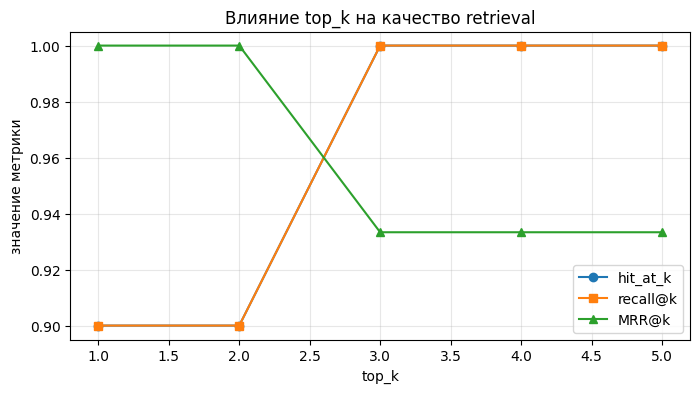

In [15]:
def compute_mrr(results_df: pd.DataFrame) -> float:
    """Вычисляет MRR (Mean Reciprocal Rank) для одного запроса"""
    first_relevant = results_df["rank_of_first_relevant"]
    valid_ranks = first_relevant[first_relevant.notna()]
    if len(valid_ranks) == 0:
        return 0.0
    return (1.0 / valid_ranks).mean()


topk_values = [1, 2, 3, 4, 5]
experiment_results = []

for top_k in topk_values:
    eval_df = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=top_k)
    mrr = compute_mrr(eval_df)

    experiment_results.append({
        "top_k": top_k,
        "mean_hit": eval_df[f"hit_at_{top_k}"].mean(),
        "mean_recall": eval_df[f"recall@{top_k}"].mean(),
        "mean_MRR": mrr,
    })

exp_df = pd.DataFrame(experiment_results)
display(exp_df)

# Визуализация
plt.figure(figsize=(8, 4))
plt.plot(exp_df["top_k"], exp_df["mean_hit"], marker="o", label="hit_at_k")
plt.plot(exp_df["top_k"], exp_df["mean_recall"], marker="s", label="recall@k")
plt.plot(exp_df["top_k"], exp_df["mean_MRR"], marker="^", label="MRR@k")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Влияние top_k на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

С увеличением top_k с 1 до 3 hit@k и recall@k значительно улучшаются.
Дальнейшее увеличение до 5 даёт незначительный прирост.
Оптимальное значение top_k для данного корпуса - 3.

## Обновление базы знаний и переиндексация

**Новые документы (2 документа):**
1. Квантовые вычисления и кубиты
2. Нейроморфные процессоры

**Цель:** Показать, что без переиндексации новые документы не находятся, а после переиндексации становятся доступны.

In [16]:
new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Квантовые вычисления и кубиты",
        "text": (
            "Квантовые компьютеры используют кубиты вместо классических битов. "
            "В отличие от обычных битов, которые могут быть только 0 или 1, кубиты могут находиться "
            "в суперпозиции состояний, что позволяет выполнять вычисления параллельно. "
            "Квантовая запутанность и интерференция — ключевые принципы работы таких систем."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Нейроморфные процессоры",
        "text": (
            "Нейроморфные вычисления имитируют архитектуру человеческого мозга. "
            "Вместо классической архитектуры фон Неймана, нейроморфные чипы используют "
            "искусственные нейроны и синапсы, что позволяет обрабатывать информацию "
            "с сверхнизким энергопотреблением, идеально для edge AI и сенсорных систем."
        ),
    },
]
updated_documents = documents + new_documents

# Запросы к новым документам
new_queries = [
    "Чем кубиты отличаются от обычных битов?",
    "Как работают нейроморфные процессоры и где они применяются?",
    "Что такое суперпозиция в квантовых вычислениях?",
]

display(pd.DataFrame(new_documents)[["doc_id", "title"]])
display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_13,Квантовые вычисления и кубиты
1,doc_14,Нейроморфные процессоры


### Как baseline-база отвечает на новые запросы

**Запрос:** Чем кубиты отличаются от обычных битов?

,rank,score,doc_id,title,chunk_text
0,1,0.310671,doc_12,Будущее технологий и тренды,"Квантовые компьютеры обещают решать задачи, не..."
1,2,0.296902,doc_06,Изобретение микропроцессора,позволили создавать программируемые калькулято...
2,3,0.281599,doc_01,Изобретение транзистора,громоздкие вакуумные лампы и позволило создава...


**Запрос:** Как работают нейроморфные процессоры и где они применяются?

,rank,score,doc_id,title,chunk_text
0,1,0.618517,doc_06,Изобретение микропроцессора,позволили создавать программируемые калькулято...
1,2,0.569672,doc_06,Изобретение микропроцессора,Первый микропроцессор Intel 4004 был создан в ...
2,3,0.476085,doc_12,Будущее технологий и тренды,"Квантовые компьютеры обещают решать задачи, не..."


**Запрос:** Что такое суперпозиция в квантовых вычислениях?

,rank,score,doc_id,title,chunk_text
0,1,0.393957,doc_12,Будущее технологий и тренды,"Квантовые компьютеры обещают решать задачи, не..."
1,2,0.292523,doc_06,Изобретение микропроцессора,позволили создавать программируемые калькулято...
2,3,0.224288,doc_01,Изобретение транзистора,громоздкие вакуумные лампы и позволило создава...


In [17]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(updated_documents, chunk_size=28, overlap=8, device=DEVICE)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

# Сохранение сравнения
comparison_rows = []
for query in new_queries:
    before = search_chunks(query, artifacts=artifacts, top_k=3)
    after = search_chunks(query, artifacts=updated_artifacts, top_k=3)
    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(before["doc_id"].tolist()),
        "after_retrieved_sources": ", ".join(after["doc_id"].tolist()),
        "changed": before["doc_id"].tolist() != after["doc_id"].tolist(),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_before_after_update.csv")
display(comparison_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


### Как updated-база отвечает на новые запросы

**Запрос:** Чем кубиты отличаются от обычных битов?

...

,rank,score,doc_id,title,chunk_text
0,1,0.739276,doc_14,Нейроморфные процессоры,Нейроморфные вычисления имитируют архитектуру ...
1,2,0.618517,doc_06,Изобретение микропроцессора,позволили создавать программируемые калькулято...
2,3,0.569672,doc_06,Изобретение микропроцессора,Первый микропроцессор Intel 4004 был создан в ...


**Запрос:** Что такое суперпозиция в квантовых вычислениях?

,rank,score,doc_id,title,chunk_text
0,1,0.737798,doc_13,Квантовые вычисления и кубиты,"могут находиться в суперпозиции состояний, что..."
1,2,0.658110,doc_13,Квантовые вычисления и кубиты,Квантовые компьютеры используют кубиты вместо ...
2,3,0.393957,doc_12,Будущее технологий и тренды,"Квантовые компьютеры обещают решать задачи, не..."



Результаты сохранены в artifacts/retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Чем кубиты отличаются от обычных битов?,"doc_12, doc_06, doc_01","doc_13, doc_13, doc_12",True
1,Как работают нейроморфные процессоры и где они...,"doc_06, doc_06, doc_12","doc_14, doc_06, doc_06",True
2,Что такое суперпозиция в квантовых вычислениях?,"doc_12, doc_06, doc_01","doc_13, doc_13, doc_12",True


## Mini-RAG

**Архитектура mini-RAG:**
1. Получение запроса пользователя
2. Поиск top-k релевантных чанков
3. Сбор контекста из найденных фрагментов
4. Формирование ответа на основе контекста
5. Возврат ответа вместе с источниками

In [18]:
import re
def split_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def build_context(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n{row['chunk_text']}"
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved


def generate_answer(query: str, context: str, max_sentences: int = 2) -> str:
    """Extractive-генератор ответа на основе контекста"""
    lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in lines if not line.startswith("[Источник:")]

    sentences = []
    for line in content_lines:
        sentences.extend(split_sentences(line))

    sentences = [s for s in sentences if len(s.split()) >= 4]

    if not sentences:
        return "Недостаточно контекста для построения ответа."

    # Простой TF-IDF для выбора наиболее релевантных предложений
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sent_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sent_vecs, axis=1) + 1e-12
    scores = (sent_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected = []
    used = set()

    for idx in ranked_idx:
        sent = sentences[idx]
        if scores[idx] <= 0 or sent.lower() in used:
            continue
        used.add(sent.lower())
        selected.append(sent)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "В найденном контексте нет достаточно релевантного фрагмента."

    return " ".join(selected)


def mini_rag(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Dict:
    context, retrieved = build_context(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer(query, context, max_sentences=2)

    return {
        "query": query,
        "answer": answer,
        "sources": retrieved[["rank", "score", "doc_id", "title", "chunk_text"]],
    }

In [19]:
# Тестирование mini-RAG
test_queries = [
    "Кто изобрел транзистор?",
    "В каком году появился первый iPhone?",
    "Что такое ARPANET?",
    "Какая компания создала Windows?",
]

rag_examples = []

for query in test_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist()),
    })

    display(Markdown(f"### Вопрос: {result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)
print("\nРезультаты сохранены в artifacts/rag_examples.csv")

### Вопрос: Кто изобрел транзистор?

**Ответ:** Транзистор был изобретен в Bell Laboratories в 1947 году учеными Уильямом Шокли, Джоном Бардином и Уолтером Браттейном.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.630585,doc_01,Изобретение транзистора,Транзистор был изобретен в Bell Laboratories в...
1,2,0.595060,doc_01,Изобретение транзистора,громоздкие вакуумные лампы и позволило создава...
2,3,0.514172,doc_06,Изобретение микропроцессора,Первый микропроцессор Intel 4004 был создан в ...


### Вопрос: В каком году появился первый iPhone?

...

### Вопрос: Какая компания создала Windows?

**Ответ:** В 1985 году Microsoft выпустила Windows 1.0, графическую оболочку для MS-DOS. Microsoft разработала MS-DOS, а затем Windows, сделав компьютеры доступными для миллионов пользователей.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.543396,doc_03,Персональные компьютеры,создавать совместимые устройства. Microsoft ра...
1,2,0.540723,doc_11,Эволюция операционных систем,В 1969 году в Bell Labs создали UNIX — многопо...
2,3,0.515694,doc_03,Персональные компьютеры,и выпустили Apple I. В 1981 году IBM представи...



Результаты сохранены в artifacts/rag_examples.csv


## Анализ ошибок

**Цель:** Выявить слабые места mini-RAG и понять причины ошибок.

In [20]:
problem_queries = [
    "сегодня хорошая погода",  # Запрос не по теме
    "как испечь пирог",        # Запрос не по теме
    "что такое квантовый компьютер",  # Частично есть в doc_12
    "кто написал Гарри Поттера",      # Нет в базе знаний
]

for query in problem_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist()),
    })

    display(Markdown(f"### Вопрос: {result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

    # Анализ
    max_score = result['sources']['score'].max()
    if max_score < 0.3:
        print("Проблема: Низкие scores - запрос не соответствует тематике базы знаний")
    elif result['answer'].startswith("Недостаточно контекста"):
        print("Проблема: Контекст содержит информацию, но генератор не смог извлечь ответ")
    else:
        print("Проблема: Запрос слишком общий или неоднозначный")



### Вопрос: сегодня хорошая погода

**Ответ:** Сегодня Bluetooth используется в наушниках, колонках, клавиатурах и для передачи файлов. Сегодня веб-технологии включают HTML5, CSS3, JavaScript и множество фреймворков.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.032547,doc_07,Технология Bluetooth,Bluetooth Low Energy (BLE) позволяет создавать...
1,2,0.029641,doc_07,Технология Bluetooth,объединившего племена. Стандарт Bluetooth 1.0 ...
2,3,0.015464,doc_09,Создание WWW и веб-технологий,"Google. Сегодня веб-технологии включают HTML5,..."


Проблема: Низкие scores - запрос не соответствует тематике базы знаний


...

### Вопрос: кто написал Гарри Поттера

**Ответ:** мира по шахматам Гарри Каспарова.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.231964,doc_04,История искусственного интеллекта,мира по шахматам Гарри Каспарова. В 2012 году ...
1,2,0.122668,doc_09,Создание WWW и веб-технологий,Тим Бернерс-Ли в 1989 году предложил концепцию...
2,3,0.111859,doc_08,История видеоигр,В 1980-х Nintendo спасла индустрию после кризи...


Проблема: Низкие scores - запрос не соответствует тематике базы знаний


## Основные типы ошибок 
1. Запросы вне предметной области → низкие scores, случайные чанки
2. Запросы, требующие синтеза информации из нескольких документов → неполный ответ
3. Запросы с синонимами → могут не найти нужный чанк из-за лексического разрыва
4. Слишком общие запросы → возвращают много тематически близких, но нерелевантных чанков
5. Отсутствие информации в базе → уверенный, но неверный ответ (галлюцинация)
